# Satellite Image Analysis for Natural Disaster Prediction

**Option 2 — Flood + wildfire detection, change detection, prediction, and damage assessment.**

This notebook walks through the full pipeline in order:

1. Kaggle dataset setup
2. Inspect the downloaded folder layout
3. Install remaining dependencies
4. Train the FloodNet U-Net (change/segmentation model)
5. Evaluate the trained model
6. Benchmark int8 quantization (compute-constraint tradeoff)
7. Flood risk *prediction* (precursor-signal prototype)
8. Unified system demo — flood before/after, fast vs. accurate mode
9. Wildfire burn-severity demo (dNBR, tiered severity)
10. Google Earth Engine — live time-series + before/after pull

> Run cells top to bottom. Shell commands (`!...`) work the same in Jupyter as in Colab.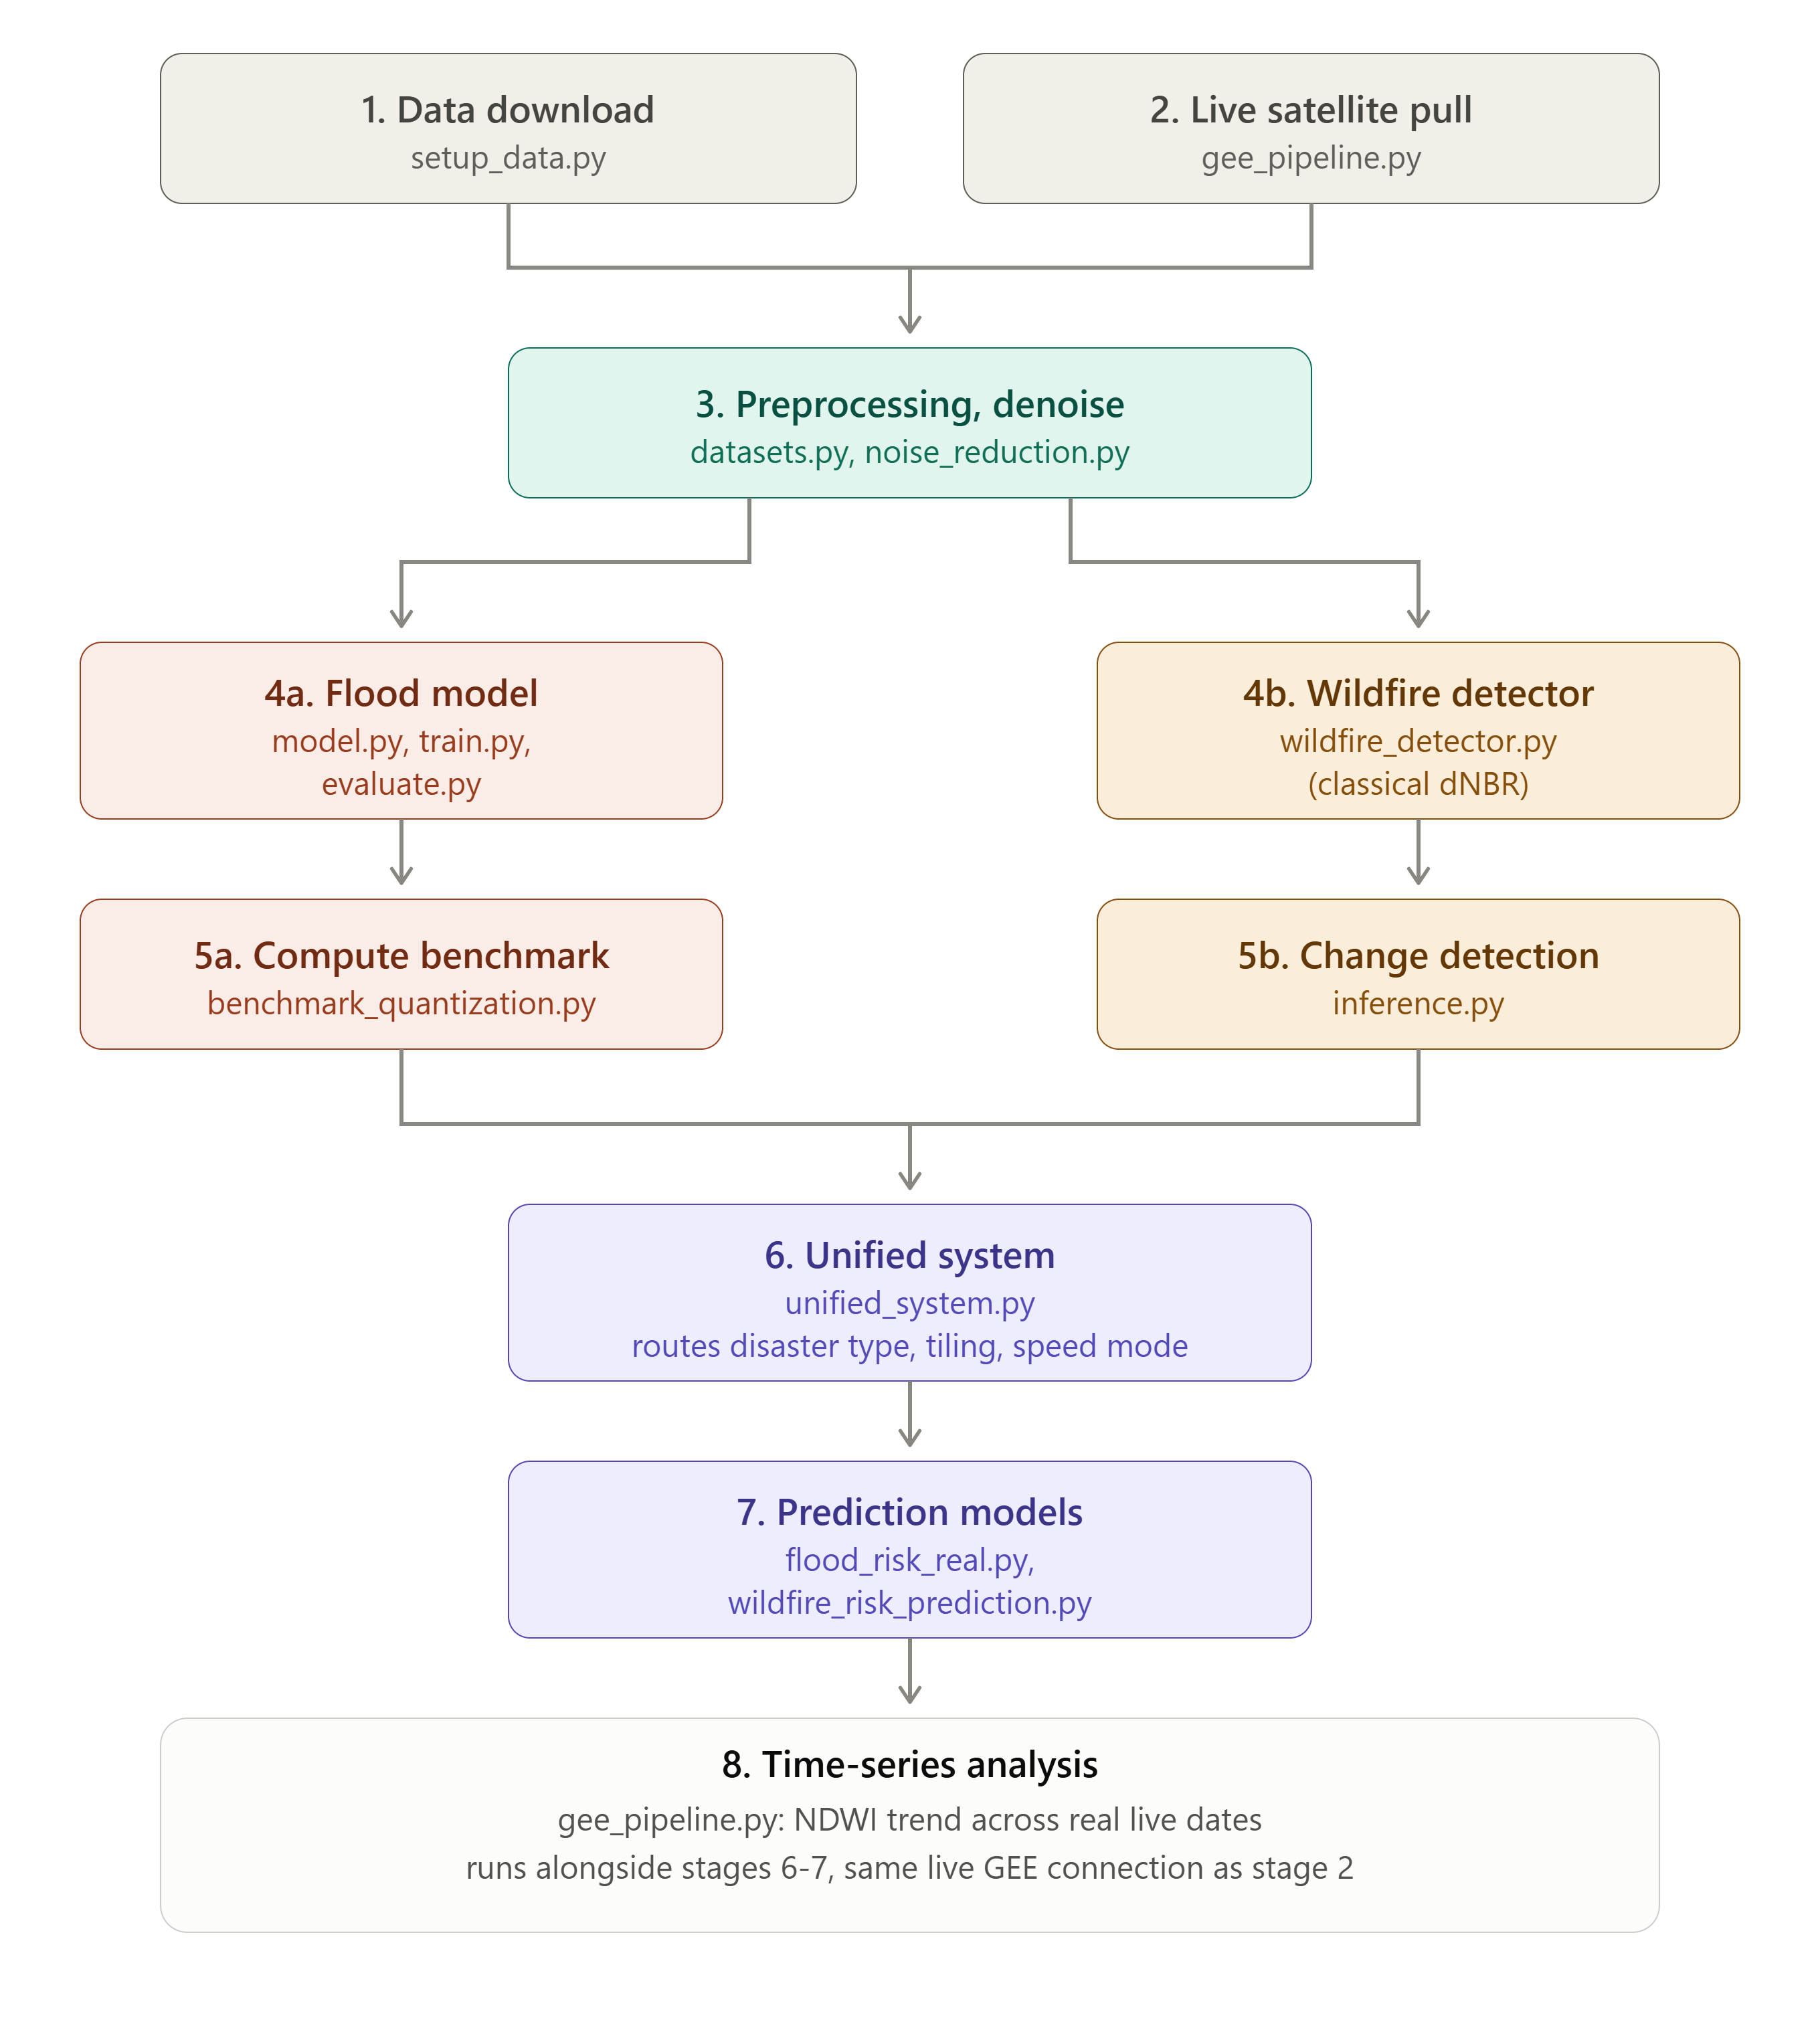

## 0. Setup & security note

In [1]:
import os

#   Option A (recommended, doesn't echo the value):
#       import getpass
#       os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("Kaggle API token: ")
#
#   Option B (Colab): upload kaggle.json when prompted by
#       check_kaggle_credentials() below -- no token needs to be typed or
#       stored in this notebook at all.
#
#   Option C (local machine): place kaggle.json at ~/.kaggle/kaggle.json
#       (chmod 600) and skip setting KAGGLE_API_TOKEN entirely.

# Uncomment to use Option A:
# import getpass
# os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("Kaggle API token: ")

os.environ["KAGGLE_API_TOKEN"] = "KGAT_7e69bd7e600b70cfca613516feb182fa"
# os.environ["KAGGLE_API_TOKEN"] = "your-KAGGLE_API_TOKEN"


## 1. Download datasets from Kaggle

Downloads both **Sen1Floods11** (8-channel SAR+optical, flood) and **FloodNet**
(UAV RGB, flood) into `data/`. Needs Kaggle credentials set up above (or a
`kaggle.json` upload prompt if running in Colab).

In [2]:
"""
setup_data.py
=============
One-time setup: downloads both datasets from Kaggle and unzips them into
the `data/` folder this project expects.

BEFORE running this, you need a Kaggle API key:
  1. Go to kaggle.com -> your profile picture -> Settings
  2. Scroll to "API" -> click "Create New Token" (downloads kaggle.json)
  3. Place it at ~/.kaggle/kaggle.json (Linux/Mac) or
     C:\\Users\\<you>\\.kaggle\\kaggle.json (Windows), or upload it when
     prompted below if running in Colab.
"""

import os
import subprocess
import sys


DATASETS = {
    "sen1floods11": "oindrieelmondal/sen1floods11-8-channel-remote-sensing-dataset",
    "floodnet": "aletbm/aerial-imagery-dataset-floodnet-challenge",
}


def check_kaggle_credentials():
    """
    Kaggle supports two auth methods -- support both so it works regardless
    of which one you set up:
      1. Newer token method: an environment variable KAGGLE_API_TOKEN, or
         a plain-text token saved at ~/.kaggle/access_token
      2. Legacy method: a kaggle.json file at ~/.kaggle/kaggle.json
    """
    if os.environ.get("KAGGLE_API_TOKEN"):
        return True

    token_path = os.path.expanduser("~/.kaggle/access_token")
    if os.path.exists(token_path):
        return True

    legacy_path = os.path.expanduser("~/.kaggle/kaggle.json")
    if os.path.exists(legacy_path):
        return True


    try:
        from google.colab import files  # noqa: F401
        print(
            "No Kaggle credentials found.\n"
            "Paste your token from kaggle.com -> Settings -> API, "
            "or press Enter to upload a kaggle.json file instead.\n"
        )
        token = input("Token (or blank to upload kaggle.json): ").strip()
        os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
        if token:
            with open(token_path, "w") as f:
                f.write(token)
            os.chmod(token_path, 0o600)
        else:
            print("Upload kaggle.json now:")
            uploaded = files.upload()
            for fname in uploaded:
                os.rename(fname, legacy_path)
            os.chmod(legacy_path, 0o600)
        return True
    except ImportError:
        pass

    print(
        "Kaggle credentials not found. Either:\n"
        "  - set the KAGGLE_API_TOKEN environment variable to your token, or\n"
        "  - save your token as plain text to ~/.kaggle/access_token, or\n"
        "  - place a legacy kaggle.json at ~/.kaggle/kaggle.json\n"
        "then re-run this cell."
    )
    return False


def download_dataset(name, kaggle_id):
    out_dir = os.path.join("data", name)
    os.makedirs(out_dir, exist_ok=True)
    print(f"\nDownloading {name} ({kaggle_id}) -> {out_dir}/ ...")
    result = subprocess.run(
        ["kaggle", "datasets", "download", "-d", kaggle_id, "-p", out_dir, "--unzip"],
        capture_output=True, text=True,
    )
    if result.returncode != 0:
        print(f"  FAILED: {result.stderr}")
        return False
    print(f"  Done. Contents:")
    for item in sorted(os.listdir(out_dir))[:10]:
        print(f"    {item}")
    return True


def main():
    if not check_kaggle_credentials():
        sys.exit(1)

    for name, kaggle_id in DATASETS.items():
        download_dataset(name, kaggle_id)

    print(
        "\nNext step: run `find data/ -maxdepth 3 -type d` to see the real "
        "folder layout inside each dataset, then update the --image_dir / "
        "--mask_dir arguments accordingly (the actual subfolder names/depth "
        "may not exactly match this project's defaults)."
    )


main()



  Done. Contents:
    dataset

  Done. Contents:
    FloodNet Challenge - Track 1
    FloodNet Challenge - Track 2

Next step: run `find data/ -maxdepth 3 -type d` to see the real folder layout inside each dataset, then update the --image_dir / --mask_dir arguments accordingly (the actual subfolder names/depth may not exactly match this project's defaults).


## 2. Inspect the downloaded folder layout

In [3]:
!find data/ -maxdepth 4 -type d


data/
data/floodnet
data/floodnet/FloodNet Challenge - Track 1
data/floodnet/FloodNet Challenge - Track 1/Validation
data/floodnet/FloodNet Challenge - Track 1/Validation/image
data/floodnet/FloodNet Challenge - Track 1/Train
data/floodnet/FloodNet Challenge - Track 1/Train/Labeled
data/floodnet/FloodNet Challenge - Track 1/Train/Unlabeled
data/floodnet/FloodNet Challenge - Track 1/Test
data/floodnet/FloodNet Challenge - Track 1/Test/image
data/floodnet/FloodNet Challenge - Track 2
data/floodnet/FloodNet Challenge - Track 2/Questions
data/floodnet/FloodNet Challenge - Track 2/Images
data/floodnet/FloodNet Challenge - Track 2/Images/Test_Image
data/floodnet/FloodNet Challenge - Track 2/Images/Valid_Image
data/floodnet/FloodNet Challenge - Track 2/Images/Train_Image
data/sen1floods11
data/sen1floods11/dataset
data/sen1floods11/dataset/data_8channel
data/sen1floods11/dataset/data_8channel/dem
data/sen1floods11/dataset/data_8channel/new_labels
data/sen1floods11/dataset/data_8channel/precip

In [4]:
!find "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled" -maxdepth 2
!ls "data/sen1floods11/dataset/Sen1Floods11_8Channel/image" | head -5
!ls "data/sen1floods11/dataset/Sen1Floods11_8Channel/label" | head -5


data/floodnet/FloodNet Challenge - Track 1/Train/Labeled
data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Flooded
data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Flooded/image
data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Flooded/mask
data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Non-Flooded
data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Non-Flooded/image
data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Non-Flooded/mask
1010394_image.tif
1017769_image.tif
1018317_image.tif
1018327_image.tif
101973_image.tif
1010394_label.tif
1017769_label.tif
1018317_label.tif
1018327_label.tif
101973_label.tif


In [5]:
!ls "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Flooded/image" | head -5
!ls "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Flooded/mask" | head -5


10165.jpg
10166.jpg
6279.jpg
6614.jpg
6615.jpg
10165_lab.png
10166_lab.png
6279_lab.png
6614_lab.png
6615_lab.png


## 3. Install remaining dependencies

In [6]:
!pip install segmentation-models-pytorch rasterio albumentations


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.6 MB/s eta 0:00:00


## 4. Train the FloodNet U-Net

Binary flood/no-flood segmentation on the 3-channel UAV RGB dataset.

Add `--full_severity --num_classes 10` instead of the defaults below to train
on the full 10-class semantic labels (building/road/water flooded vs.
non-flooded) instead of the collapsed binary mask -- gives real damage-tier
output for Technical Task 5 (damage assessment).

In [7]:
!python train.py --dataset floodnet \
    --root_dir "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled" \
    --in_channels 3 --epochs 5 --checkpoint floodnet_unet.pt


Using device: cuda
Loaded 398 image/mask pairs.
config.json: 100% 156/156 [00:00<00:00, 576kB/s]

model.safetensors: downloading bytes:  93% 43.4M/46.8M [00:01<00:00, 51.5MB/s, 2.69MB/s  ]
model.safetensors: downloading bytes: 100% 43.4M/43.4M [00:01<00:00, 23.3MB/s, 4.10MB/s  ]
model.safetensors: reconstructing file: 100% 46.8M/46.8M [00:01<00:00, 25.1MB/s, 4.46MB/s  ]
Epoch 1/5 [train]: 100% 40/40 [01:01<00:00,  1.54s/it]
Epoch 1/5 [val]: 100% 10/10 [00:16<00:00,  1.61s/it]
Epoch 1: train_loss=0.6219, val_iou=0.6149
  -> saved new best checkpoint (IoU=0.6149)
Epoch 2/5 [train]: 100% 40/40 [01:01<00:00,  1.53s/it]
Epoch 2/5 [val]: 100% 10/10 [00:14<00:00,  1.44s/it]
Epoch 2: train_loss=0.3724, val_iou=0.7661
  -> saved new best checkpoint (IoU=0.7661)
Epoch 3/5 [train]: 100% 40/40 [01:02<00:00,  1.55s/it]
Epoch 3/5 [val]: 100% 10/10 [00:14<00:00,  1.46s/it]
Epoch 3: train_loss=0.2930, val_iou=0.7536
Epoch 4/5 [train]: 100% 40/40 [00:59<00:00,  1.49s/it]
Epoch 4/5 [val]: 100% 10/10 [00

## 5. Evaluate the trained model




In [8]:
!python evaluate.py --dataset floodnet \
    --root_dir "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled" \
    --in_channels 3 --checkpoint floodnet_unet.pt


Overall IoU: 0.7262
Saved 4 example predictions to eval_examples/


## 6. Benchmark int8 quantization

Concrete numbers for the "limited computational power" requirement: model
size, per-image inference time, and IoU, original vs. quantized.

In [9]:
!python benchmark_quantization.py --checkpoint floodnet_unet.pt \
    --root_dir "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled" \
    --in_channels 3


/content/benchmark_quantization.py:75: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(

--- Quantization Benchmark ---
Metric              Original       Quantized      Change         
Model size (MB)     54.76          54.76          +0.0%
Time/image (sec)    0.6998         0.6924         -1.1%
IoU                 0.5

## 8. Unified system demo — flood, before/after

Single entry point (`unified_system.py`) handling both disaster types, with
a `--mode fast|accurate` tradeoff (accurate now actually denoises using the
bilateral filter in `noise_reduction.py` before inference) and `--tile_size`
for images larger than the model was trained on.

In [10]:
!ls "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Non-Flooded/image" | head -3
!ls "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Flooded/image" | head -3


10175.jpg
10176.jpg
10687.jpg
10165.jpg
10166.jpg
6279.jpg


In [11]:
!python unified_system.py --disaster_type flood \
    --before "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Non-Flooded/image/10175.jpg" \
    --after "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Flooded/image/10165.jpg" \
    --checkpoint floodnet_unet.pt --in_channels 3 --mode accurate


Saved: results/before_mask.png
Saved: results/after_mask.png
Saved: results/change_newly_flooded.png

Mode: accurate | Tile size: None | Total time: 18.07s


In [12]:
!python unified_system.py --disaster_type flood \
    --before "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Non-Flooded/image/10175.jpg" \
    --after "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Flooded/image/10165.jpg" \
    --checkpoint floodnet_unet.pt --in_channels 3 --mode fast


Saved: results/before_mask.png
Saved: results/after_mask.png
Saved: results/change_newly_flooded.png

Mode: fast | Tile size: None | Total time: 4.22s


## 9. Wildfire burn-severity demo

Classical dNBR (Normalized Burn Ratio difference) approach — no training
run needed. Requires a real before/after Sentinel-2 GeoTIFF pair with known
NIR/SWIR band indices (see the Earth Engine section below for how to pull
one). Now outputs **tiered severity** (unburned/low/moderate-low/
moderate-high/high, USGS convention) instead of a single binary mask, and
`--denoise` applies the bilateral filter before computing NBR.

In [13]:
# # Uncomment once you have real before/after GeoTIFFs (see section 10 for
# # download_sentinel2_geotiff, which produces files usable here):
# #
# !python unified_system.py --disaster_type wildfire \
#     --before before_fire.tif --after after_fire.tif \
#     --nir_band 0 --swir_band 2 --mode accurate


## 10. Google Earth Engine — live time-series & before/after pull

Two things this section adds beyond the downloaded Kaggle images:

- **Time-series analysis** (Technical Task 1): NDWI trend over real dates,
  not just a single snapshot.
- **Live inference inputs**: a real before/after Sentinel-1 pair, or a
  downloaded Sentinel-2 GeoTIFF pair usable by `wildfire_detector.py`.

Run the authentication cell once per session.

In [14]:
import ee
ee.Authenticate()
ee.Initialize(project='disaster-project-508518')
print(ee.Number(1).getInfo())

# import ee
# ee.Authenticate()
# ee.Initialize(project='your-project-id')
# print(ee.Number(1).getInfo())


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


1


In [15]:
from gee_pipeline import get_ndwi_time_series

dates, values = get_ndwi_time_series(31.5497, 74.3436, days_back=60)
for d, v in zip(dates, values):
    print(d, v)


2026-08-16 -0.45308449974079834
2026-08-24 -0.51672671127123
2026-08-24 -0.5186891961085509
2026-08-29 -0.1613165379926859
2026-09-03 -0.46146146146146144
2026-09-03 -0.5410504844467109
2026-09-05 -0.6643428866511748
2026-09-08 -0.665
2026-09-08 -0.6971971971971972
2026-09-08 -0.6553657914861075
2026-09-08 -0.67396841569027
2026-09-13 -0.015463917525773196
2026-09-13 0.048
2026-09-18 -0.794686613360846
2026-09-18 -0.6404437720625316


Optional: download a real Sentinel-2 before/after GeoTIFF pair to feed
into the wildfire demo in section 9.

In [16]:
from gee_pipeline import download_sentinel2_geotiff
#
download_sentinel2_geotiff(34.05, -118.5, "2025-01-01", "before_fire.tif")
download_sentinel2_geotiff(34.05, -118.5, "2025-02-01", "after_fire.tif")


Saved: before_fire.tif (bands: ('B8', 'B4', 'B12'))
Saved: after_fire.tif (bands: ('B8', 'B4', 'B12'))


'after_fire.tif'

In [17]:
!python unified_system.py --disaster_type wildfire \
    --before before_fire.tif --after after_fire.tif \
    --nir_band 0 --swir_band 2 --mode accurate

Saved burn mask: results/burn_severity.tif
Burned area: 23.05% of image
Saved severity tiers (0-4): results/burn_severity_severity.tif
  unburned       76.95%
  low            8.03%
  moderate_low   4.48%
  moderate_high  5.39%
  high           5.16%

Mode: accurate | Tile size: None | Total time: 0.41s


/tmp/ipykernel_1353/898991896.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("YlOrRd", 5)


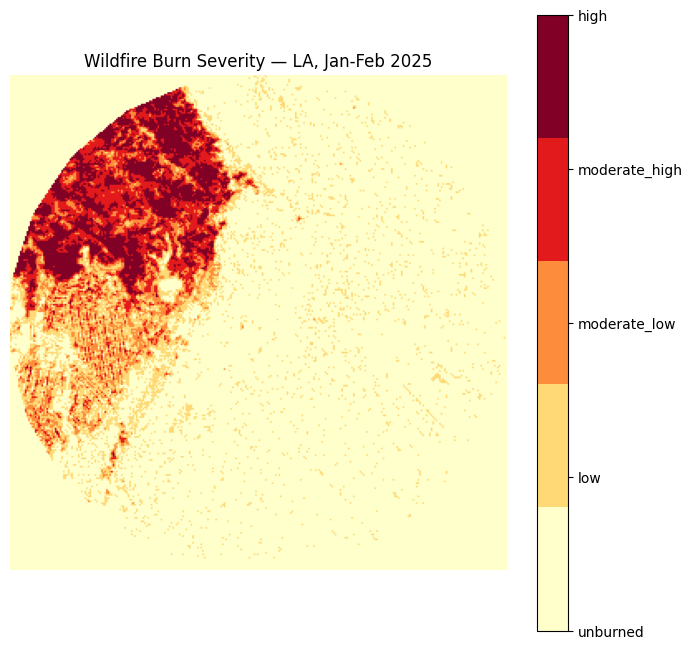

In [18]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

with rasterio.open("results/burn_severity_severity.tif") as src:
    severity = src.read(1)

labels = ["unburned", "low", "moderate_low", "moderate_high", "high"]
cmap = plt.cm.get_cmap("YlOrRd", 5)

plt.figure(figsize=(8, 8))
im = plt.imshow(severity, cmap=cmap, vmin=0, vmax=4)
cbar = plt.colorbar(im, ticks=range(5))
cbar.ax.set_yticklabels(labels)
plt.title("Wildfire Burn Severity — LA, Jan-Feb 2025")
plt.axis("off")
plt.savefig("results/severity_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
!python unified_system.py --disaster_type wildfire \
    --before before_fire.tif --after after_fire.tif \
    --nir_band 0 --swir_band 2 --mode fast

Saved burn mask: results/burn_severity.tif
Burned area: 23.06% of image
Saved severity tiers (0-4): results/burn_severity_severity.tif
  unburned       76.94%
  low            8.03%
  moderate_low   4.48%
  moderate_high  5.39%
  high           5.16%

Mode: fast | Tile size: None | Total time: 0.07s


In [20]:
!python train.py --dataset sen1floods11 \
    --image_dir "data/sen1floods11/dataset/Sen1Floods11_8Channel/image" \
    --mask_dir "data/sen1floods11/dataset/Sen1Floods11_8Channel/label" \
    --in_channels 8 --epochs 3 --checkpoint sen1floods_unet.pt

Using device: cuda
Loaded 446 image/mask pairs.
Epoch 1/3 [train]: 100% 45/45 [00:22<00:00,  2.04it/s]
Epoch 1/3 [val]: 100% 12/12 [00:04<00:00,  2.66it/s]
Epoch 1: train_loss=nan, val_iou=0.4319
  -> saved new best checkpoint (IoU=0.4319)
Epoch 2/3 [train]: 100% 45/45 [00:19<00:00,  2.25it/s]
Epoch 2/3 [val]: 100% 12/12 [00:03<00:00,  3.10it/s]
Epoch 2: train_loss=nan, val_iou=0.4319
Epoch 3/3 [train]: 100% 45/45 [00:18<00:00,  2.38it/s]
Epoch 3/3 [val]: 100% 12/12 [00:02<00:00,  4.08it/s]
Epoch 3: train_loss=nan, val_iou=0.4319


In [21]:
!python train.py --dataset floodnet \
    --root_dir "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled" \
    --in_channels 3 --epochs 5 --full_severity --num_classes 10 --checkpoint floodnet_severity.pt

Using device: cuda
Loaded 398 image/mask pairs.
Epoch 1/5 [train]: 100% 40/40 [00:58<00:00,  1.46s/it]
Epoch 1/5 [val]: 100% 10/10 [00:14<00:00,  1.48s/it]
Epoch 1: train_loss=1.9674, val_iou=0.1550
  -> saved new best checkpoint (IoU=0.1550)
Epoch 2/5 [train]: 100% 40/40 [01:00<00:00,  1.52s/it]
Epoch 2/5 [val]: 100% 10/10 [00:13<00:00,  1.39s/it]
Epoch 2: train_loss=1.4534, val_iou=0.2181
  -> saved new best checkpoint (IoU=0.2181)
Epoch 3/5 [train]: 100% 40/40 [00:59<00:00,  1.49s/it]
Epoch 3/5 [val]: 100% 10/10 [00:13<00:00,  1.37s/it]
Epoch 3: train_loss=1.1978, val_iou=0.2578
  -> saved new best checkpoint (IoU=0.2578)
Epoch 4/5 [train]: 100% 40/40 [00:58<00:00,  1.46s/it]
Epoch 4/5 [val]: 100% 10/10 [00:13<00:00,  1.39s/it]
Epoch 4: train_loss=0.9749, val_iou=0.2843
  -> saved new best checkpoint (IoU=0.2843)
Epoch 5/5 [train]: 100% 40/40 [00:57<00:00,  1.44s/it]
Epoch 5/5 [val]: 100% 10/10 [00:14<00:00,  1.43s/it]
Epoch 5: train_loss=0.8734, val_iou=0.2992
  -> saved new best c

/tmp/ipykernel_1353/781439620.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("YlOrRd", 5)


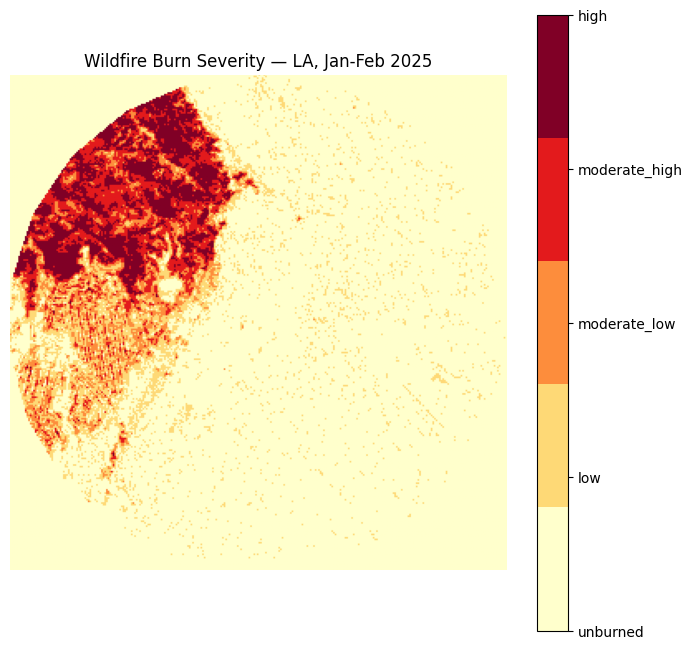

In [22]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("results/burn_severity_severity.tif") as src:
    severity = src.read(1)

labels = ["unburned", "low", "moderate_low", "moderate_high", "high"]
cmap = plt.cm.get_cmap("YlOrRd", 5)
plt.figure(figsize=(8, 8))
im = plt.imshow(severity, cmap=cmap, vmin=0, vmax=4)
cbar = plt.colorbar(im, ticks=range(5))
cbar.ax.set_yticklabels(labels)
plt.title("Wildfire Burn Severity — LA, Jan-Feb 2025")
plt.axis("off")
plt.savefig("results/severity_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
!python unified_system.py --disaster_type wildfire \
    --before before_fire.tif --after after_fire.tif \
    --nir_band 0 --swir_band 2 --mode fast

Saved burn mask: results/burn_severity.tif
Burned area: 23.06% of image
Saved severity tiers (0-4): results/burn_severity_severity.tif
  unburned       76.94%
  low            8.03%
  moderate_low   4.48%
  moderate_high  5.39%
  high           5.16%

Mode: fast | Tile size: None | Total time: 0.06s


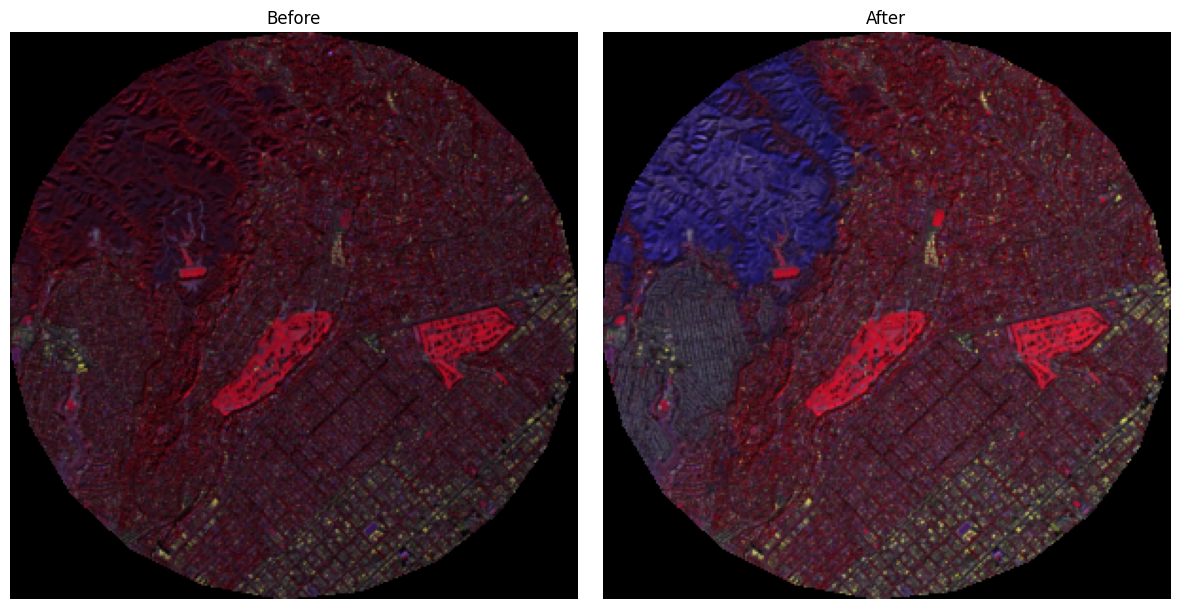

In [24]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, path, title in zip(axes, ["before_fire.tif", "after_fire.tif"], ["Before", "After"]):
    with rasterio.open(path) as src:
        img = src.read([1, 2, 3]).astype(np.float32)  # B8, B4, B12
        img = np.transpose(img, (1, 2, 0))
        img = (img - img.min()) / (img.max() - img.min() + 1e-6)  # normalize for display
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig("results/before_after_preview.png", dpi=150)
plt.show()

In [25]:
!ls *.py

benchmark_quantization.py  gen_charts.py       unified_system.py
datasets.py		   inference.py        wildfire_detector.py
evaluate.py		   model.py	       wildfire_risk_prediction.py
flood_prediction_v2.py	   noise_reduction.py
gee_pipeline.py		   train.py


In [26]:
!pip install ucimlrepo
!python wildfire_risk_prediction.py

Dropped 1 row(s) with malformed values in the raw dataset
Loaded 243 REAL records from the Algerian Forest Fires dataset
  Fire days:     137
  Non-fire days: 106
  Features used: ['Temperature', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']

Wildfire risk prediction -- trained on REAL historical data
  Accuracy:  0.984
  Precision: 0.971
  Recall:    1.000
  F1 score:  0.986

Confusion matrix (test set, n=61):
  True negatives:  26   False positives: 1
  False negatives: 0   True positives:  34

Feature weights (standardized -- higher magnitude = more influence):
  ISI            +2.432
  FFMC           +2.409
  FWI            +1.957
  DMC            -0.339
  BUI            +0.336
  Temperature    +0.140
  DC             +0.041

Note: small sample (244 records, one season, one country) -- treat these metrics as evidence the pipeline works on real data, not as a validated production-ready predictor.
Saved: results_wildfire_prediction.json


In [27]:
import ee
ee.Authenticate()
ee.Initialize(project='disaster-project-508518')

In [28]:
!grep -n "def get_current_ndwi" /content/gee_pipeline.py

161:def get_current_ndwi(lat, lon, window_days=15, buffer_meters=500):


In [29]:
import ee
ee.Authenticate()
ee.Initialize(project='disaster-project-508518')
print(ee.Number(1).getInfo())  # should print 1

1


 Flood risk prediction

In [30]:
!python -u flood_prediction_v2.py --n_events 60 --days_back 30

Pulling 60 real flood events from GLOBAL_FLOOD_DB...
*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python
Got 60 real events

Building real precursor-NDWI dataset (this makes real GEE calls, may take a few minutes)...
  Skipping positive sample for event 4369 (no imagery in window)
  Skipping negative sample for event 4369 (no imagery in window)
  Skipping positive sample for event 4376 (no imagery in window)
  Skipping negative sample for event 4376 (no imagery in window)
  Skipping positive sample for event 4378 (no imagery in window)
  Skipping negative sample for event 4378 (no imagery in window)
  [FLOOD]  South Africa    2016-07-25  mean_ndwi=-0.5120 slope=-0.00115
  Skipping negative sample for event 4381 (no imagery in window)
  Skipping positive sample for event 4382 (no imagery in window)
  Skipping negative sample for event 4382 (no imagery in window)
  [FLOOD]  USA

In [31]:
!python gen_charts.py

No results_ndwi_timeseries.json found yet -- using previously recorded real run (re-run the source script to refresh)
Using real saved results: results_wildfire_prediction.json
Using real saved results: results_timing.json
Using real saved results: results_quantization.json

Generated 5 charts in /content/
